In [1]:
import random
random.seed(42)
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('white')
sns.set_style('ticks')
#import bcolz
import pandas
import allel; print('scikit-allel', allel.__version__)
%reload_ext memory_profiler
from itertools import compress
from collections import *
from functools import reduce
import pandas as pd

scikit-allel 1.3.5


In [2]:
#callset = allel.read_vcf("/Users/rainlam/Project/3.SV/phasing/LG4.phased.vcf.gz")
callset = allel.read_vcf("/Users/rainlam/Project/FR24.phased.vcf")

In [3]:
genotype = allel.GenotypeChunkedArray(callset['calldata/GT'])
a, b, c = genotype.shape
a,b,c

(5842921, 12, 2)

In [4]:
# creat an array contains all True 
genotype_phased = np.array([[True for x in range(b)] for i in range(a)])
#genotypes phasing 
genotype.is_phased = genotype_phased

In [5]:
genotype_phased.shape

(5842921, 12)

In [6]:
hap = genotype.to_haplotypes()
hap

<HaplotypeChunkedArray shape=(5842921, 24) dtype=int8 chunks=(43690, 24)
   nbytes=133.7M cbytes=18.1M cratio=7.4
   compression=gzip compression_opts=1
   values=h5py._hl.dataset.Dataset>

In [7]:
#sampleNames = 
#sampleNames = callset['samples']
sampleNames = np.array([[i + "_H1", i +"_H2"] for i in callset['samples']]).reshape(24,)
sampleNames 

array(['P271_H1', 'P271_H2', 'P433_H1', 'P433_H2', 'P436_H1', 'P436_H2',
       'P437_H1', 'P437_H2', 'P438_H1', 'P438_H2', 'P444_H1', 'P444_H2',
       'P445_H1', 'P445_H2', 'P450_H1', 'P450_H2', 'P452_H1', 'P452_H2',
       'P455_H1', 'P455_H2', 'P456_H1', 'P456_H2', 'P461_H1', 'P461_H2'],
      dtype='<U7')

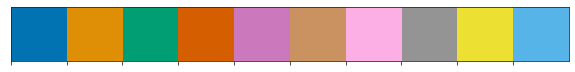

In [8]:
palette = sns.color_palette('colorblind')
sns.palplot(palette)

In [9]:
def plot_transmission(painting, title=None):
    
    # set figure height depending on number of haplotypes
    fig, ax = plt.subplots(figsize=(12, .2 * painting.shape[1]), dpi=500)
    
    # map painting codes onto colours
    cmap = mpl.colors.ListedColormap([
        'grey',      # 0 = undetermined
        palette[0],  # 1 = allele inherited from first parental haplotype
        palette[2],  # 2 = allele inherited from second parental haplotype
        palette[1],  # 3 = reference allele, also carried by both parental haplotypes
        palette[3],  # 4 = non-reference allele, also carried by both parental haplotypes
        'black',     # 5 = non-parental allele (i.e., Mendelian error)
        palette[5],  # 6 = either or both parental alleles missing
        'white',     # 7 = missing allele
    ])
    
    # plot painting
    ax.pcolormesh(painting.T, cmap=cmap, vmin=0, vmax=7)
    
    # tidy up axes
    ax.set_yticks(np.arange(painting.shape[1]) + .5)
    ax.set_yticklabels(sampleNames )
    ax.set_ylabel('Haplotypes')
    ax.set_xlabel('Variants')
    if title:
        ax.set_title(title)

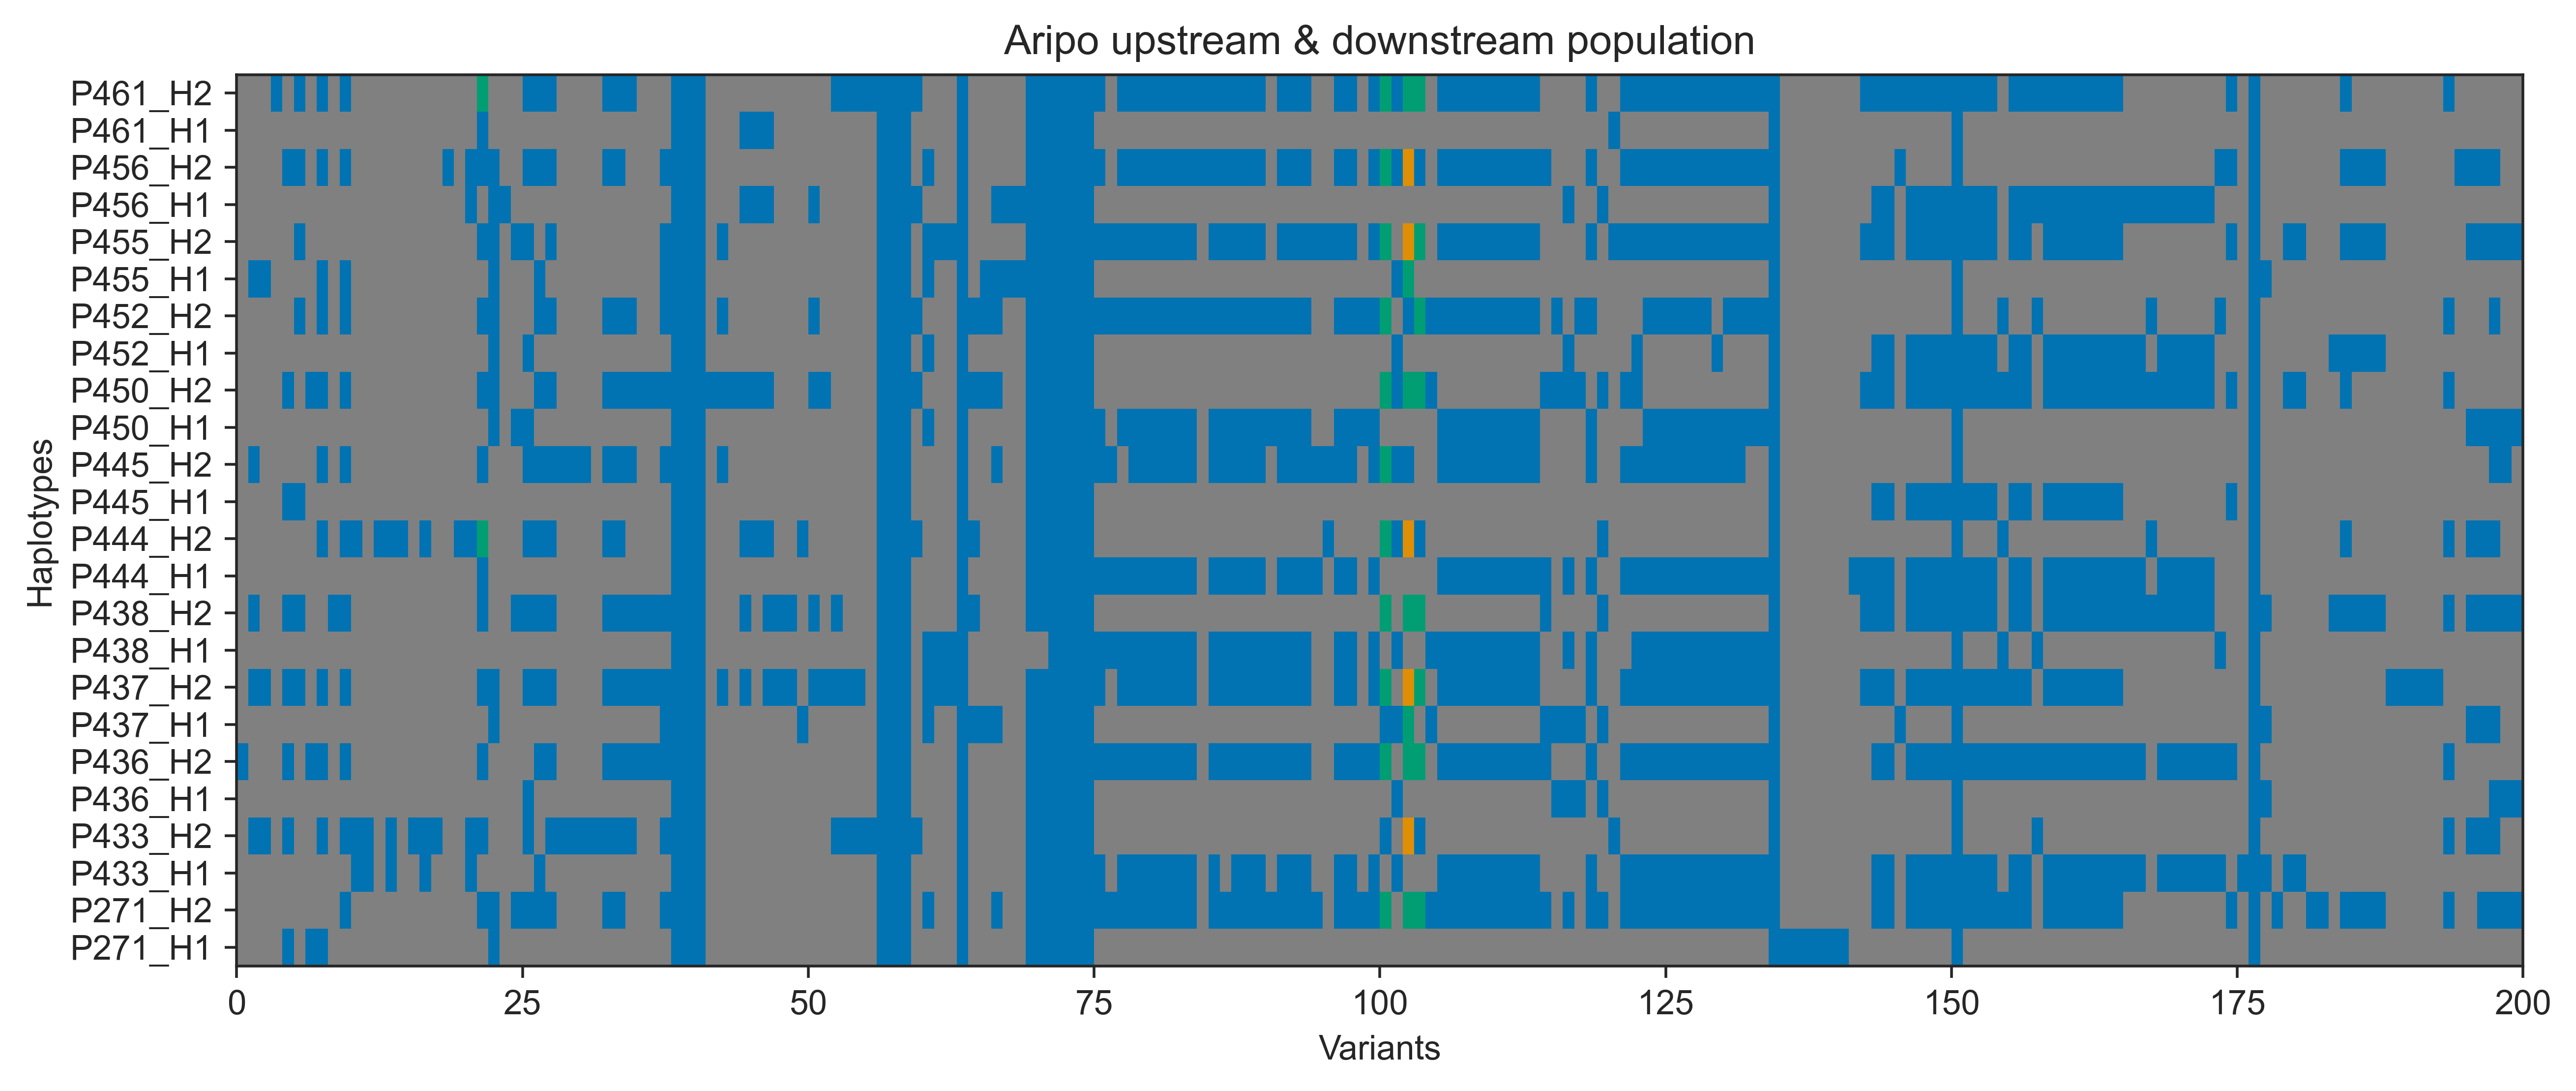

In [13]:
import matplotlib as mpl
plot_transmission(hap[:200, :], title='Aripo upstream & downstream population')

In [116]:
hap

<HaplotypeChunkedArray shape=(212611, 240) dtype=int8 chunks=(4369, 240)
   nbytes=48.7M cbytes=6.2M cratio=7.8
   compression=gzip compression_opts=1
   values=h5py._hl.dataset.Dataset>

In [57]:
callset["variants/POS"][-9786:]

array([29235291, 29235443, 29235454, ..., 31495879, 31496005, 31496675],
      dtype=int32)

In [21]:
range(hap.shape[1])

range(0, 240)

In [41]:
AripoSamples = np.array([[i + "_P", i +"_M"] for i in ['ArH-F10', 'ArH-F11', 'ArH-F13', 'ArH-F14', 'ArH-F1', 'ArH-F23',
        'ARH-F24', 'ArH-F25', 'ARH-F2', 'ArH-F9', 'ArH-M12', 'ARH-M16',
        'ArH-M19', 'ARH-M1', 'ArH-M21', 'ArH-M24', 'ArH-M2', 'ArH-M5',
        'ArH-M7', 'ArH-M9', 'ArL-F10', 'ArL-F15', 'ArL-F16', 'ArL-F18',
        'ArL-F19', 'ArL-F20', 'ArL-F22', 'ArL-F5', 'ArL-F8', 'ArL-F9',
        'ArL-M11', 'ArL-M12', 'ARL-M15', 'ArL-M16', 'ARL-M17', 'ArL-M19',
        'ArL-M1', 'ArL-M24', 'ARL-M25', 'ArL-M6']]).reshape(80,)
xlabels = callset[]

In [30]:
hap[-13769:, :40]

<HaplotypeArray shape=(13769, 40) dtype=int8>
1 0 1 1 0 ... 0 1 1 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 1 1 ... 0 0 1 0 1
1 1 0 1 1 ... 1 0 1 1 1
0 0 0 0 0 ... 0 0 0 0 0

In [49]:
callset["variants/POS"][-13769:]

array([28683448, 28683871, 28684485, ..., 31495879, 31496005, 31496675],
      dtype=int32)

In [46]:
1/100

0.01